# Radiance Field Network


In [1]:
import json

import matplotlib.pyplot as plt
import torch
import wandb
from torchinfo import summary
from utils import read_ground_truth_zip, preprocess_data, create_image

from radiance_field_network import RadianceFieldNetwork
from train import train_model

GROUND_TRUTH_FILE = '../data/radiance/chameleon_front.zip'

WANDB_PROJECT = 'neural-volume-illumination'
WANDB_NAME = 'radiance-field-network'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Indirect Radiance Data


In [2]:
data, parameters = read_ground_truth_zip(GROUND_TRUTH_FILE, verbose=True)
print(f'Loaded {len(data)} frames from ground truth zip.')
print(f'Frame shape: {data[0].shape}')
print(f'Parameters: {parameters}')

Reading ground truth zip: 100%|██████████| 514/514 [00:13<00:00, 36.75it/s]

Loaded 512 frames from ground truth zip.
Frame shape: (262144, 8)
Parameters: {'extinction': 200, 'anisotropy': 0, 'samples': 5, 'bounces': 50, 'steps': 500, 'accumulate': False, 'stochastic': True, 'resolution': 512}


In [3]:
Xs, ys, masks = preprocess_data(data, device, verbose=True)

Preprocessing data: 100%|██████████| 512/512 [00:04<00:00, 123.73it/s]


## Training and Evaluation


In [4]:
def train(Xs, ys, epochs, lr, model_args, verbose=False):
    with wandb.init(
        project=WANDB_PROJECT,
        name=WANDB_NAME,
        config={
            'epochs': epochs,
            'learning_rate': lr,
            'model_args': model_args,
        },
    ) as run:
        return train_model(Xs, ys, device, epochs, lr, model_args, verbose, run)


In [5]:
# comfy-sweep-15
fast_model_args = json.load(open('../data/configs/model_parameters/fast.json', 'r'))

# giddy-sweep-13
best_model_args = json.load(open('../data/configs/model_parameters/best.json', 'r'))

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/blaz/.netrc.
wandb: Currently logged in as: blazerzar (blazerzar-team) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


100%|██████████| 511/511 [00:20<00:00, 24.95it/s, ms=13.1, train_loss=0.0573, val_loss=0.0573]


baseline_loss,▄▁▆▄▂▅▅▄▆▆▃▆▁▃▄▂▃▁▄▂█▄▅▅▅▄▅▄▃▃▄▅▆▆▂▅▆▅▂▄
ms,██▂▁▁▂▂▂▁▃▂▂▂▂▂▂▂▂▂▁▂▃▁▃▂▃▂▂▃▂▂▁▂▃▂▂▂▁▂▂
train_loss,█▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▅▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
baseline_loss,0.08144
ms,13.11761
train_loss,0.05729
val_loss,0.05729


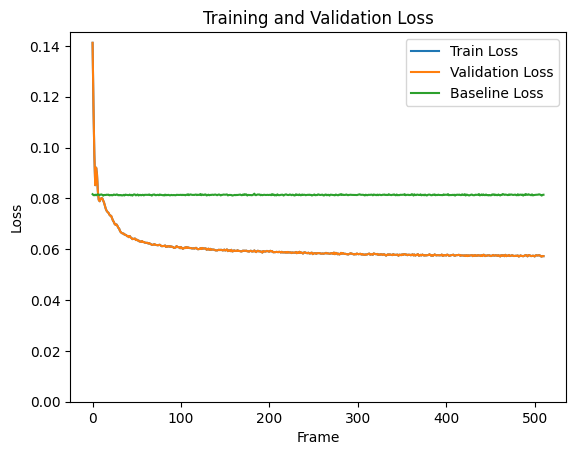

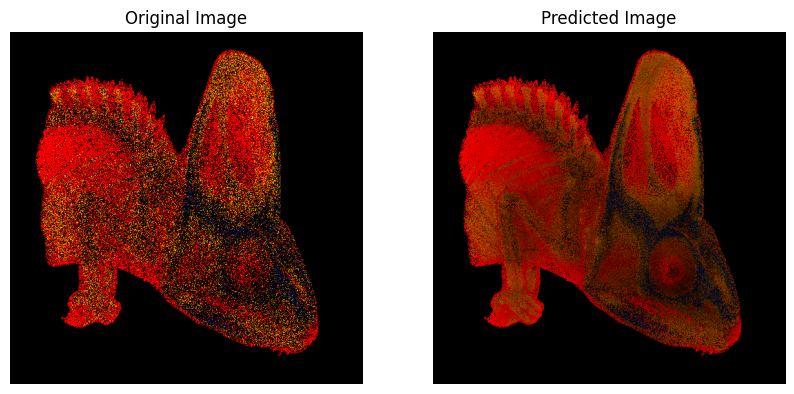

In [6]:
torch.manual_seed(1)
model, train_losses, val_losses, baseline_losses = train(
    Xs[:-1], ys[:-1], verbose=True, **fast_model_args
)

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.plot(baseline_losses, label='Baseline Loss')
plt.xlabel('Frame')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.ylim(bottom=0)
plt.legend()
plt.show()

original = create_image(ys[-1], masks[-1], parameters['resolution'])
predicted = create_image(model(Xs[-1]), masks[-1], parameters['resolution'])

_, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].imshow(original)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(predicted)
ax[1].set_title('Predicted Image')
ax[1].axis('off')
plt.show()

In [11]:
summary(RadianceFieldNetwork(), input_size=Xs[0].shape)

Layer (type:depth-idx)                   Output Shape              Param #
RadianceFieldNetwork                     [118637, 3]               --
├─MultiresolutionHashEncoding: 1-1       [118637, 32]              --
│    └─ModuleList: 2-1                   --                        --
│    │    └─Embedding: 3-1               [118637, 8, 2]            9,826
│    │    └─Embedding: 3-2               [118637, 8, 2]            18,522
│    │    └─Embedding: 3-3               [118637, 8, 2]            32,768
│    │    └─Embedding: 3-4               [118637, 8, 2]            32,768
│    │    └─Embedding: 3-5               [118637, 8, 2]            32,768
│    │    └─Embedding: 3-6               [118637, 8, 2]            32,768
│    │    └─Embedding: 3-7               [118637, 8, 2]            32,768
│    │    └─Embedding: 3-8               [118637, 8, 2]            32,768
│    │    └─Embedding: 3-9               [118637, 8, 2]            32,768
│    │    └─Embedding: 3-10              [118637, 

In [18]:
plt.imsave('original.png', original)

In [60]:
plt.imsave('predicted.png', predicted)